# Object Detection Tasks
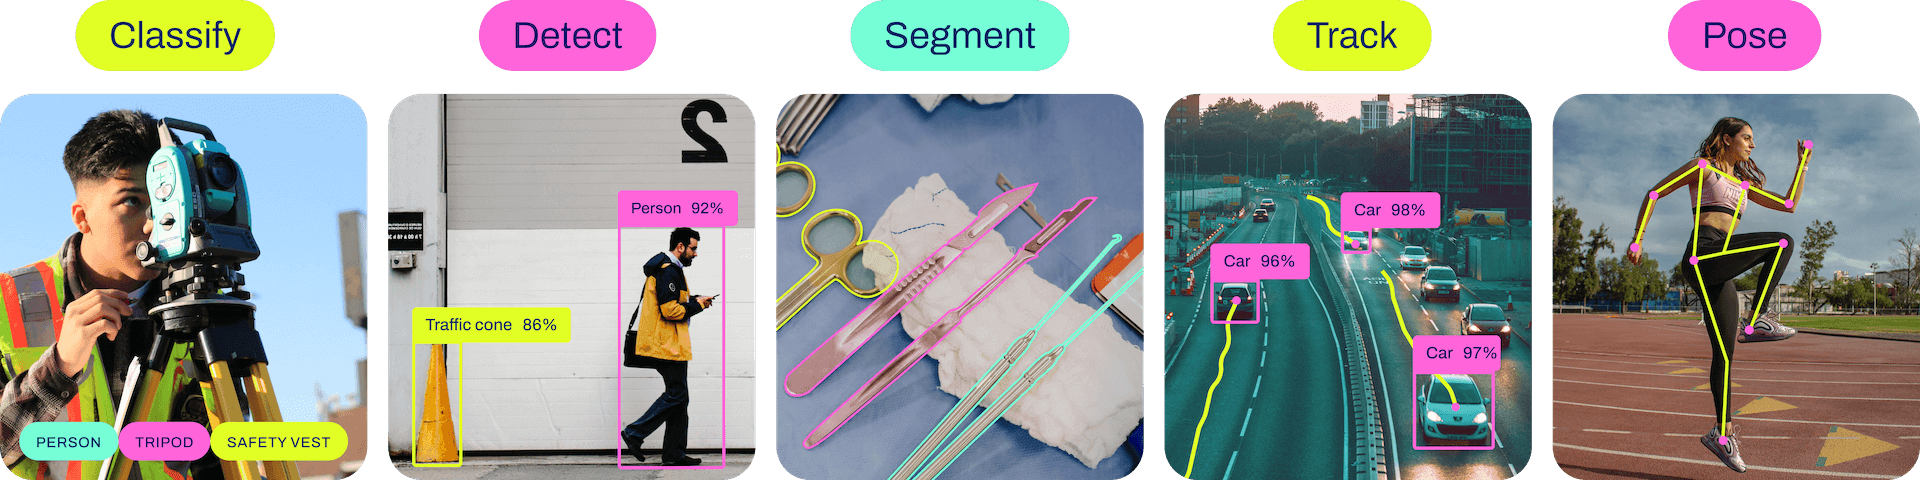

# Haar Cascades

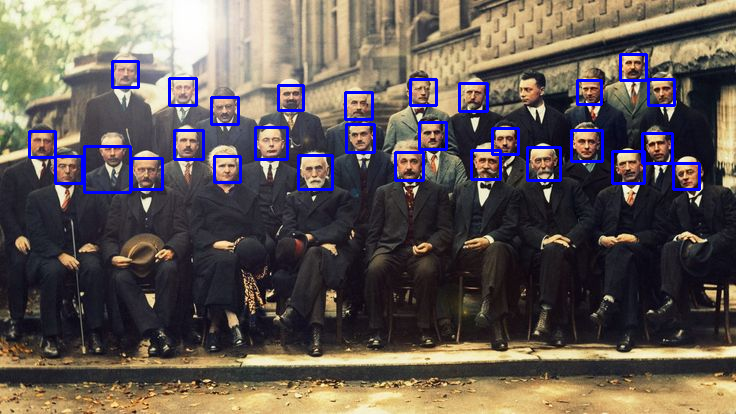

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow


face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')


img = cv2.imread("/content/img2.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.2, 1)


for (x,y,w,h) in faces:
    img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

cv2_imshow(img)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
    import cv2
    import os

    image_path = "/img.jpg" # Replace with your actual path

    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
    else:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error: Failed to load image from {image_path}. It might be corrupted or unreadable.")
        else:
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Further processing

Error: Image file not found at /img.jpg


# Playing with Yolo v8

In [15]:
!pip install ultralytics

import ultralytics

ultralytics.checks()

Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.1/107.7 GB disk)


### 1. Predict

YOLOv8 may be used directly in the Command Line Interface (CLI) with a `yolo` command for a variety of tasks and modes and accepts additional arguments, i.e. `imgsz=640`. See a full list of available `yolo` [arguments](https://docs.ultralytics.com/usage/cfg/) and other details in the [YOLOv8 Predict Docs](https://docs.ultralytics.com/modes/train/).


In [17]:
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'

Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 806.6ms
Speed: 19.3ms preprocess, 806.6ms inference, 17.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


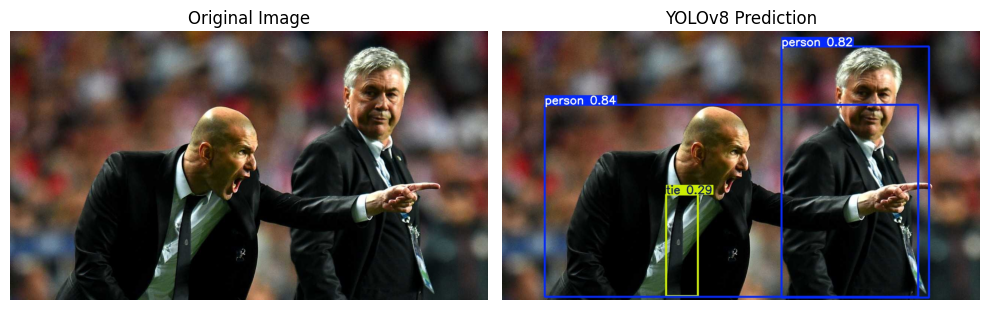

In [18]:
import matplotlib.pyplot as plt

img1 = cv2.imread("zidane.jpg")
img2 = cv2.imread("/content/runs/detect/predict/zidane.jpg")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the images in the subplots
axes[0].imshow(img1_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off') # Hide axes

axes[1].imshow(img2_rgb)
axes[1].set_title("YOLOv8 Prediction")
axes[1].axis('off') # Hide axes

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 176.6ms
Speed: 4.9ms preprocess, 176.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


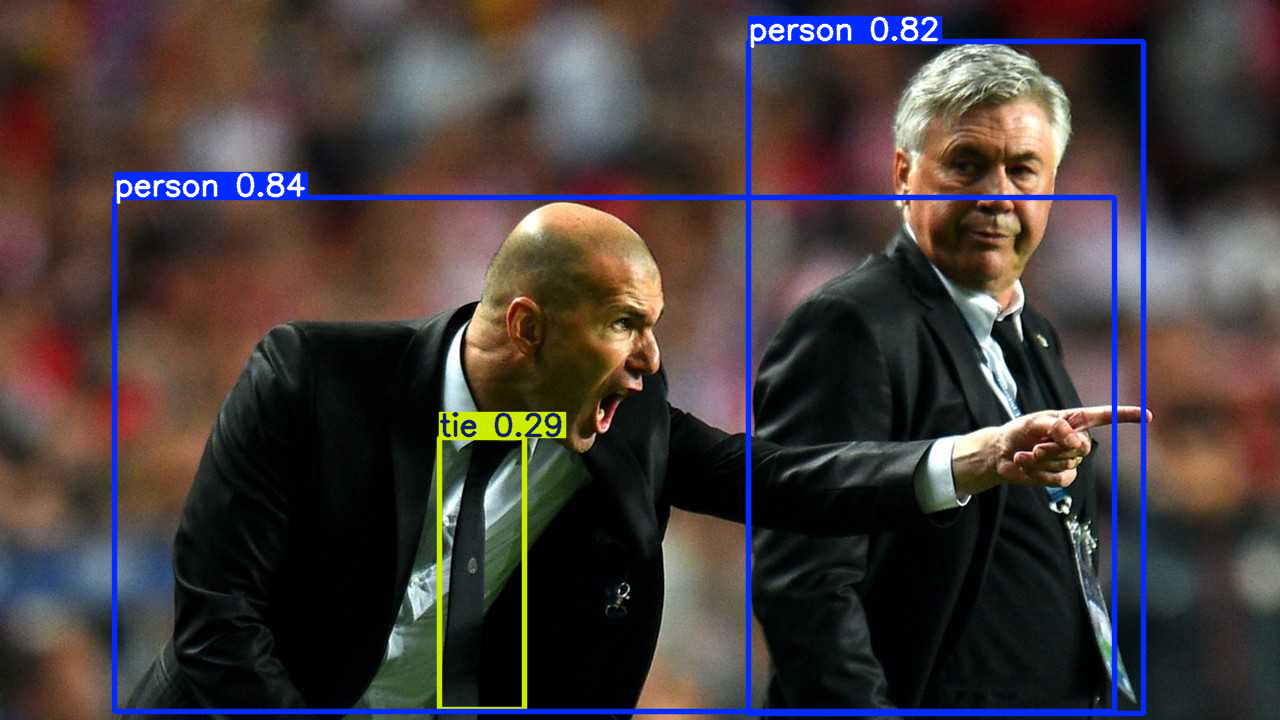

In [19]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

model = YOLO('yolov8n.pt')

results = model('https://ultralytics.com/images/zidane.jpg')

annotated_img = results[0].plot()

cv2_imshow(annotated_img)

In [20]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

# Initialize the YOLO model
model = YOLO('yolov8n.pt')

# Initialize video capture from the default camera (usually 0)
# If you have multiple cameras, you might need to change the index
cap = cv2.VideoCapture(0)

# Check if the camera opened successfully
if not cap.isOpened():
    print("Error: Could not open camera.")
    exit()

# Loop through the video frames
while cap.isOpened():
    # Read a frame from the video capture
    success, frame = cap.read()

    if success:
        # Run YOLOv8 inference on the frame
        results = model(frame)

        # Visualize the results on the frame
        annotated_frame = results[0].plot()

        # Display the annotated frame
        cv2_imshow(annotated_frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        # Break the loop if the end of the video is reached
        break

# Release the video capture object and close the display window
cap.release()
cv2.destroyAllWindows()

Error: Could not open camera.


## Face Resolution Enhancement with UNET

This project on Kaggle shows how to improve the quality of blurry faces in images using a special type of neural network called **UNET**.

Think of UNET like a smart artist that can take a low-quality picture of a face and make it look sharper and more detailed. This project provides the code and steps to do that.

Here's the link to the project:

https://www.kaggle.com/code/ashishjangra27/face-resolution-enhancement-with-unet

## Assignment: Face Resolution Enhancement

**Goal:** The objective of this assignment is to implement a solution that takes a low-resolution face image (64x64 pixels) as input and produces a high-resolution, enhanced face image (256x256 pixels) using a UNET model.

This assignment is based on the concepts and techniques demonstrated in the following Kaggle notebook:

[https://www.kaggle.com/code/ashishjangra27/face-resolution-enhancement-with-unet](https://www.kaggle.com/code/ashishjangra27/face-resolution-enhancement-with-unet)

You will need to refer to this resource to understand how to:

1.  Load or define the UNET model architecture.
2.  Load and preprocess the input image to the required 64x64 size.
3.  Apply the UNET model to the input image.
4.  Handle the output to obtain the 256x256 enhanced image.
5.  (Optional but recommended) Display both the original 64x64 image and the resulting 256x256 image for comparison.

This assignment focuses on applying the knowledge gained from the provided resource to a specific image enhancement task.

In [1]:
import os
import cv2 as cv
import numpy as np

import matplotlib.pyplot as plt

from keras.models import Model, load_model
from keras.layers import Input, BatchNormalization, Activation, Dense, Dropout
from keras.layers import Conv2D, Conv2DTranspose
from keras.layers import MaxPooling2D, GlobalMaxPool2D
from keras.layers import concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
import tensorflow as tf

In [21]:
def unet_64to128(input_shape=(64, 64, 3), n_classes=3, final_activation='sigmoid', dropout_rate=0.05):
    inputs = Input(shape=input_shape, name='img')

    # Encoder
    c1 = Conv2D(16, (3,3), padding='same')(inputs)
    c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    c1 = Conv2D(16, (3,3), padding='same')(c1)
    c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    p1 = MaxPooling2D((2,2))(c1); p1 = Dropout(dropout_rate)(p1)   # 64 -> 32

    c2 = Conv2D(32, (3,3), padding='same')(p1)
    c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    c2 = Conv2D(32, (3,3), padding='same')(c2)
    c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    p2 = MaxPooling2D((2,2))(c2); p2 = Dropout(dropout_rate)(p2)   # 32 -> 16

    c3 = Conv2D(64, (3,3), padding='same')(p2)
    c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)
    c3 = Conv2D(64, (3,3), padding='same')(c3)
    c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)
    p3 = MaxPooling2D((2,2))(c3); p3 = Dropout(dropout_rate)(p3)   # 16 -> 8

    c4 = Conv2D(128, (3,3), padding='same')(p3)
    c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    c4 = Conv2D(128, (3,3), padding='same')(c4)
    c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    p4 = MaxPooling2D((2,2))(c4); p4 = Dropout(dropout_rate)(p4)   # 8 -> 4

    c5 = Conv2D(256, (3,3), padding='same')(p3)
    c5 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    c5 = Conv2D(256, (3,3), padding='same')(c4)
    c5 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    p5 = MaxPooling2D((2,2))(c4); p4 = Dropout(dropout_rate)(p4)   # 8 -> 4

    # Bottleneck (4x4)
    c5 = Conv2D(256, (3,3), padding='same')(p4)
    c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)
    c5 = Conv2D(256, (3,3), padding='same')(c5)
    c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)

    # Decoder (back to 64x64)
    u6 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(c5)  # 4 -> 8
    u6 = concatenate([u6, c4]); u6 = Dropout(dropout_rate)(u6)
    u6 = Conv2D(128, (3,3), padding='same')(u6)
    u6 = BatchNormalization()(u6); u6 = Activation('relu')(u6)
    u6 = Conv2D(128, (3,3), padding='same')(u6)
    u6 = BatchNormalization()(u6); u6 = Activation('relu')(u6)

    u7 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(u6)    # 8 -> 16
    u7 = concatenate([u7, c3]); u7 = Dropout(dropout_rate)(u7)
    u7 = Conv2D(64, (3,3), padding='same')(u7)
    u7 = BatchNormalization()(u7); u7 = Activation('relu')(u7)
    u7 = Conv2D(64, (3,3), padding='same')(u7)
    u7 = BatchNormalization()(u7); u7 = Activation('relu')(u7)

    u8 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(u7)    # 16 -> 32
    u8 = concatenate([u8, c2]); u8 = Dropout(dropout_rate)(u8)
    u8 = Conv2D(32, (3,3), padding='same')(u8)
    u8 = BatchNormalization()(u8); u8 = Activation('relu')(u8)
    u8 = Conv2D(32, (3,3), padding='same')(u8)
    u8 = BatchNormalization()(u8); u8 = Activation('relu')(u8)

    u9 = Conv2DTranspose(16, (3,3), strides=(2,2), padding='same')(u8)    # 32 -> 64
    u9 = concatenate([u9, c1]); u9 = Dropout(dropout_rate)(u9)
    u9 = Conv2D(16, (3,3), padding='same')(u9)
    u9 = BatchNormalization()(u9); u9 = Activation('relu')(u9)
    u9 = Conv2D(16, (3,3), padding='same')(u9)
    u9 = BatchNormalization()(u9); u9 = Activation('relu')(u9)

    # Extra upsample to reach 128x128 (no skip)
    u10 = Conv2DTranspose(16, (3,3), strides=(2,2), padding='same')(u9)   # 64 -> 128
    u10 = Dropout(dropout_rate)(u10)
    u10 = Conv2D(16, (3,3), padding='same')(u10)
    u10 = BatchNormalization()(u10); u10 = Activation('relu')(u10)

        # Extra upsample to reach 128x128 (no skip)
    u11 = Conv2DTranspose(8, (3,3), strides=(2,2), padding='same')(u10)   # 128 -> 256
    u11 = Dropout(dropout_rate)(u11)
    u11 = Conv2D(16, (3,3), padding='same')(u11)
    u10 = BatchNormalization()(u11); u11 = Activation('relu')(u11)

    outputs = Conv2D(n_classes, (1,1), activation=final_activation, name='mask')(u11)

    return Model(inputs=inputs, outputs=outputs, name='UNet_128to256')


In [23]:
model = unet_64to128(input_shape=(64,64,3), n_classes=3, final_activation='sigmoid')

print('Input shape:', model.input_shape)   # (None, 64, 64, 3)
print('Output shape:', model.output_shape) # (None, 256, 256, 3)

model.compile(optimizer=Adam(1e-4), loss='mae' )

Input shape: (None, 64, 64, 3)
Output shape: (None, 256, 256, 3)


In [30]:
import os
import cv2 as cv
import numpy as np

imgs = os.listdir('/content/drive/MyDrive/celeb 64 x 64/')


def datagen(batch_size):

    while True:
        x_batch = []
        y_batch = []

        for _ in range(batch_size):
            indx = np.random.randint(0, len(imgs))

            bgr = cv.imread('/content/drive/MyDrive/celeb 64 x 64/' + imgs[indx])
            bgr = cv.resize(bgr, (256, 256))
            rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

            # blur = cv.blur(rgb, (4, 4))

            x = cv.resize(rgb, (64, 64))
            x = x / 255.0
            y = rgb / 255.0

            x_batch.append(x)
            y_batch.append(y)

        x_batch = np.array(x_batch).reshape(batch_size, 64, 64, 3)
        y_batch = np.array(y_batch).reshape(batch_size, 256, 256, 3)

        yield x_batch, y_batch

In [31]:
batch_size = 32

batch_size = 32
num_images = len(imgs)
steps_per_epoch = num_images // batch_size


results = model.fit(datagen(batch_size=batch_size), steps_per_epoch=steps_per_epoch , epochs=5, verbose=1)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - loss: 0.2494
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 159s 5s/step - loss: 0.2357
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 158s 5s/step - loss: 0.2159
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 159s 5s/step - loss: 0.1843
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 158s 5s/step - loss: 0.1487


In [ ]:
import os, cv2 as cv, numpy as np, matplotlib.pyplot as plt, tensorflow as tf

def show_and_save_samples(model, imgs, base_dir, epoch, n=5, save_dir='./epoch_samples'):
    os.makedirs(save_dir, exist_ok=True)
    chosen = np.random.choice(imgs, n, replace=False)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1: axes = np.expand_dims(axes, 0)

    for i, fname in enumerate(chosen):
        path = os.path.join(base_dir, fname)
        rgb = cv.cvtColor(cv.imread(path), cv.COLOR_BGR2RGB)
        gt128 = cv.resize(rgb, (128,128)).astype('float32')/255
        img64 = cv.resize(rgb, (64,64)).astype('float32')/255
        pred  = model.predict(np.expand_dims(img64,0), verbose=0)[0]
        lowup = cv.resize((img64*255).astype(np.uint8),(128,128))

        for ax, im, title in zip(axes[i],[rgb,gt128,lowup,pred],
                                 ['Original','GT 128x128','Low-Res','Prediction']):
            ax.imshow(im); ax.set_title(title); ax.axis('off')

    plt.tight_layout(); plt.savefig(f"{save_dir}/epoch_{epoch+1:02d}.png"); plt.show()

# --- Simple Callbacks ---
def on_epoch_end(epoch, logs):
    show_and_save_samples(model, imgs, base_dir, epoch, n=5)
    model.save(f'./checkpoints/model_epoch_{epoch+1:02d}.keras')

show_cb = tf.keras.callbacks.LambdaCallback(on_epoch_end=on_epoch_end)


batch_size = 32
steps_per_epoch = len(imgs)//batch_size
base_dir = '/content/drive/MyDrive/celeb 64 x 64/'
os.makedirs('./checkpoints', exist_ok=True)

results = model.fit(
    datagen(batch_size=batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=3,
    callbacks=[show_cb],
    verbose=1)

Epoch 1/3
 9/32 ━━━━━━━━━━━━━━━━━━━━ 1:51 5s/step - loss: 0.1119